In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!pip install pennylane torch scikit-learn matplotlib

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.1/57.1 kB 5.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.8/4.8 MB 59.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 930.8/930.8 kB 38.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.6/2.6 MB 81.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 11.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 167.9/167.9 kB 11.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.6/8.6 MB 18.4 MB/s eta 0:00:00


In [ ]:
import numpy as np
import pandas as pd
import torch
from torch import nn
from torch.optim import Adam
import pennylane as qml
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import matplotlib.pyplot as plt
import torch.nn.functional as F
from pennylane.qnn import TorchLayer


In [ ]:
csv_path = '/content/drive/MyDrive/dataset/autoencoder_regression_dataset.csv'

# Load the dataset
df = pd.read_csv(csv_path)
data = df.to_numpy()

# Display shape
print("Shape:", df.shape)
df.head()

Shape: (98664, 18)


,auto1,auto2,auto3,auto4,auto5,auto6,auto7,auto8,R_p,g_p,Temp,log_kappa_cloud,log_P_cloud,log_H2O,log_CO2,log_CO,log_CH4,log_NH3
0,-6.900868,-2.257141,0.207701,4.832452,3.164491,-3.497359,-0.399868,-3.593274,1.658348,17.176982,3327.875478,-3.855474,-3.844470,-8.889865,-4.018888,-3.195541,-7.868857,-5.895533
1,-1.916458,-3.192332,-2.223765,5.931571,4.592133,-4.370333,0.607382,-0.963816,0.258443,16.036432,2034.071133,-3.014919,-2.962217,-3.225697,-2.038615,-5.329029,-3.169883,-3.206833
2,-2.968401,-4.461657,0.615572,6.173611,3.366025,-3.686306,1.251608,-2.651082,0.503774,9.066010,1712.661454,-2.246068,-1.677456,-3.993484,-2.895214,-7.397882,-8.908273,-7.172669
3,-6.847833,-1.085600,1.159278,6.646182,2.965960,-3.345752,1.183463,-3.545845,0.562965,7.254639,3287.260930,-1.086659,-3.761693,-8.448541,-3.301345,-4.516020,-7.289866,-7.753208
4,-6.317009,-2.666278,0.357277,5.979415,3.764004,-3.740373,0.478526,-2.697041,0.745250,35.230361,2895.010899,-1.323324,-1.794849,-8.350682,-4.666140,-6.680365,-6.197769,-5.475105


In [ ]:

df.describe()

,auto1,auto2,auto3,auto4,auto5,auto6,auto7,auto8,R_p,g_p,Temp,log_kappa_cloud,log_P_cloud,log_H2O,log_CO2,log_CO,log_CH4,log_NH3
count,98664.000000,98664.000000,98664.000000,98664.000000,98664.000000,98664.000000,98664.000000,98664.000000,98664.000000,98664.000000,98664.000000,98664.000000,98664.000000,98664.000000,98664.000000,98664.000000,98664.000000,98664.000000
mean,0.432125,-3.457424,-3.516597,3.565911,4.389943,-3.945479,0.114160,-1.418761,1.060991,22.680367,1990.529089,-3.203587,-1.506352,-5.497066,-5.490777,-5.500600,-5.500026,-5.508865
std,3.234254,1.967700,3.186135,1.796521,1.560807,1.812092,2.572931,1.960795,0.542885,10.043365,866.480792,2.187283,1.445999,2.021719,2.020946,2.027659,2.023330,2.020505
min,-14.811619,-15.821565,-34.447407,-10.412514,-0.998671,-8.042172,-17.367699,-17.314592,0.100042,5.000412,500.059513,-6.999982,-3.999971,-8.999924,-8.999969,-8.999911,-8.999990,-8.999985
25%,-1.607159,-4.582289,-4.866113,2.445690,3.396904,-5.127968,-1.442510,-2.488036,0.593661,14.036827,1238.898762,-5.087822,-2.762471,-7.250021,-7.239419,-7.264763,-7.260083,-7.261356
50%,1.228101,-3.437524,-2.951968,3.444859,4.215981,-4.415377,0.642672,-1.233767,1.061147,22.724996,1986.033911,-3.215291,-1.504305,-5.488896,-5.485339,-5.499874,-5.502937,-5.508495
75%,2.808834,-2.111875,-1.699876,4.814338,5.243215,-3.260385,2.143631,-0.132477,1.531775,31.344526,2737.571477,-1.317402,-0.255494,-3.753459,-3.741738,-3.740803,-3.745523,-3.763974
max,8.470268,1.421151,3.338503,8.002897,16.989565,12.363155,5.335825,3.258902,1.999990,39.999593,3499.933503,0.599861,0.999957,-2.000011,-2.000260,-2.000041,-2.000107,-2.000021


In [ ]:
def prepare_data(df, target_col, test_size=0.2, val_size=0.2, random_state=42):
    """
    Prepares data for quantum-classical hybrid regression (torch tensors).

    Args:
        df (pd.DataFrame): Input dataframe.
        target_col (str): Column name of target variable.
        test_size (float): Fraction of test data.
        val_size (float): Fraction of validation data (from train split).
        random_state (int): Random seed.

    Returns:
        X_train, X_val, X_test (torch.Tensor): Classical input features.
        y_train, y_val, y_test (torch.Tensor): Targets.
    """

    X = df.iloc[:, :8].values.astype(np.float32)

    X_norm = X / np.linalg.norm(X, axis=1, keepdims=True)

    y = df[target_col].values.astype(np.float32).reshape(-1, 1)

    X_train, X_temp, y_train, y_temp = train_test_split(
        X_norm, y, test_size=test_size, random_state=random_state
    )
    X_val, X_test, y_val, y_test = train_test_split(
        X_temp, y_temp, test_size=val_size, random_state=random_state
    )

    # Convert to torch tensors (exactly like your H2O code)
    X_train = torch.tensor(X_train, dtype=torch.float32)
    X_val   = torch.tensor(X_val, dtype=torch.float32)
    X_test  = torch.tensor(X_test, dtype=torch.float32)
    y_train = torch.tensor(y_train, dtype=torch.float32)
    y_val   = torch.tensor(y_val, dtype=torch.float32)
    y_test  = torch.tensor(y_test, dtype=torch.float32)

    return X_train, X_val, X_test, y_train, y_val, y_test

In [ ]:
def build_model(n_features=8, n_qubits=3, n_layers=2, n_outputs=1):
    """
    Builds the quantum-classical hybrid model with the same parameters as H2O code.

    Args:
        n_features (int): Number of classical input features (default 8).
        n_qubits (int): Number of qubits in QNN.
        n_layers (int): Number of layers in the QNN.
        n_outputs (int): Number of outputs (default 1).

    Returns:
        model (nn.Module): BalancedHybridModel instance.
    """

    # Quantum device
    dev = qml.device("default.qubit", wires=n_qubits)

    # Quantum circuit
    @qml.qnode(dev, interface="torch", diff_method="backprop")
    def quantum_circuit(inputs, weights):
        qml.AmplitudeEmbedding(inputs, wires=range(n_qubits), normalize=True)
        qml.StronglyEntanglingLayers(weights, wires=range(n_qubits))
        return [qml.expval(qml.PauliZ(i)) for i in range(n_qubits)]

    # QNN TorchLayer
    weight_shapes = {"weights": (n_layers, n_qubits, 3)}
    qlayer = TorchLayer(quantum_circuit, weight_shapes)

    # Hybrid Model
    class BalancedHybridModel(nn.Module):
        def __init__(self, qlayer, n_qubits, n_outputs):
            super().__init__()
            self.fc1 = nn.Linear(n_features, 64)
            self.bn1 = nn.BatchNorm1d(64)
            self.fc2 = nn.Linear(64, 32)
            self.bn2 = nn.BatchNorm1d(32)

            self.qnn = qlayer
            self.fc_fuse1 = nn.Linear(32 + n_qubits, 32)
            self.fc_fuse2 = nn.Linear(32, n_outputs)

        def forward(self, x_classical, x_quantum):
            c = F.relu(self.bn1(self.fc1(x_classical)))
            c = F.relu(self.bn2(self.fc2(c)))
            q = self.qnn(x_quantum)
            x = torch.cat([c, q], dim=1)
            x = F.relu(self.fc_fuse1(x))
            out = self.fc_fuse2(x)
            return out

    # Instantiate model
    model = BalancedHybridModel(qlayer, n_qubits, n_outputs)

    return model

In [ ]:

def train_model(model,
                X_train, X_val, X_test,
                y_train, y_val, y_test,
                target_name,
                epochs=100, batch_size=32, lr=0.001, patience=20,
                save_dir="/content/drive/MyDrive/"):
    """
    Trains the BalancedHybridModel with early stopping and saves model per target.

    Args:
        model (nn.Module): Hybrid model instance.
        X_train, X_val, X_test (torch.Tensor): Input features.
        y_train, y_val, y_test (torch.Tensor): Targets.
        target_name (str): Name of the atmospheric parameter (used for save path).
        epochs (int): Maximum number of epochs.
        batch_size (int): Batch size.
        lr (float): Learning rate.
        patience (int): Early stopping patience.
        save_dir (str): Directory to save best model weights.

    Returns:
        model (nn.Module): Trained model with best weights loaded.
        history (dict): Training history with 'loss', 'val_loss', 'mae', 'val_mae'.
    """

    save_path = f"{save_dir}qnn_best_{target_name}.pth"

    optimizer = Adam(model.parameters(), lr=lr)
    loss_fn = nn.MSELoss()

    best_val_loss = float("inf")
    wait = 0
    history = {"loss": [], "val_loss": [], "mae": [], "val_mae": []}

    for epoch in range(epochs):
        model.train()
        idx = torch.randperm(X_train.size(0))
        batch_losses, batch_mae = [], []

        for i in range(0, X_train.size(0), batch_size):
            batch_idx = idx[i:i+batch_size]
            xb, yb = X_train[batch_idx], y_train[batch_idx]

            optimizer.zero_grad()
            preds = model(xb, xb)
            loss = loss_fn(preds, yb)
            loss.backward()
            optimizer.step()

            batch_losses.append(loss.item())
            batch_mae.append(torch.mean(torch.abs(preds - yb)).item())

        # Training metrics
        train_loss = np.mean(batch_losses)
        train_mae = np.mean(batch_mae)

        model.eval()
        with torch.no_grad():
            val_preds = model(X_val, X_val)
            val_loss = loss_fn(val_preds, y_val).item()
            val_mae = torch.mean(torch.abs(val_preds - y_val)).item()


        history["loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["mae"].append(train_mae)
        history["val_mae"].append(val_mae)

        print(f"Epoch {epoch+1}/{epochs}, "
              f"Train MSE: {train_loss:.4f}, Val MSE: {val_loss:.4f}, "
              f"Train MAE: {train_mae:.4f}, Val MAE: {val_mae:.4f}")

        # Early stopping
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            wait = 0
            torch.save(model.state_dict(), save_path)
        else:
            wait += 1
            if wait >= patience:
                print("Early stopping triggered.")
                break

    # Load best model
    model.load_state_dict(torch.load(save_path))
    model.eval()

    return model, history


In [ ]:
def compute_metrics(model, X_test, y_test):
    """
    Computes RMSE, MAE, and R2 for a trained model on the test set.

    Args:
        model (nn.Module): Trained model.
        X_test (torch.Tensor): Test inputs.
        y_test (torch.Tensor): Test targets.

    Returns:
        metrics (dict): Dictionary with 'rmse', 'mae', 'r2'.
        y_pred (np.ndarray): Model predictions as numpy array.
    """
    model.eval()
    with torch.no_grad():
        y_pred = model(X_test, X_test).numpy()

    metrics = {
        "rmse": np.sqrt(mean_squared_error(y_test, y_pred)),
        "mae": mean_absolute_error(y_test, y_pred),
        "r2": r2_score(y_test, y_pred)
    }

    print(f"\nTest Metrics:")
    print(f"RMSE={metrics['rmse']:.3f}, MAE={metrics['mae']:.3f}, R²={metrics['r2']:.3f}")

    return metrics, y_pred

In [ ]:
def plot_training_and_results(history, model, X_test, y_test, target_name):
    """
    Plots training curves (MSE & MAE) and scatter plot of true vs predicted.

    Args:
        history (dict): Training history with keys 'loss', 'val_loss', 'mae', 'val_mae'.
        model (nn.Module): Trained model.
        X_test (torch.Tensor): Test features.
        y_test (torch.Tensor): Test targets.
        target_name (str): Name of the target parameter (for titles).
    """
    import matplotlib.pyplot as plt
    model.eval()

    fig, axes = plt.subplots(1, 2, figsize=(14,5))

    # MSE
    axes[0].plot(history['loss'], label='Train MSE')
    axes[0].plot(history['val_loss'], label='Val MSE')
    axes[0].set_xlabel("Epochs")
    axes[0].set_ylabel("MSE")
    axes[0].set_title(f"MSE Curve ({target_name})")
    axes[0].legend()

    # MAE
    axes[1].plot(history['mae'], label='Train MAE')
    axes[1].plot(history['val_mae'], label='Val MAE')
    axes[1].set_xlabel("Epochs")
    axes[1].set_ylabel("MAE")
    axes[1].set_title(f"MAE Curve ({target_name})")
    axes[1].legend()

    plt.tight_layout()
    plt.show()

    print("\n" * 5)

    # Scatter plot: True vs Predicted
    with torch.no_grad():
        y_pred = model(X_test, X_test).numpy()

    plt.figure(figsize=(6,6))
    plt.scatter(y_test, y_pred, alpha=0.6)
    plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
    plt.xlabel(f"True {target_name}")
    plt.ylabel(f"Predicted {target_name}")
    plt.title(f"True vs Predicted ({target_name})")
    plt.show()

In [ ]:
def show_random_predictions(model, X_test, y_test, n_samples=20, target_name="Target"):
    """
    Displays predictions for a random subset of test samples.

    Args:
        model (nn.Module): Trained model.
        X_test (torch.Tensor): Test features.
        y_test (torch.Tensor): Test targets.
        n_samples (int): Number of random samples to display.
        target_name (str): Name of the target parameter (for display).
    """
    model.eval()
    with torch.no_grad():
        idx = torch.randperm(X_test.size(0))[:n_samples]
        X_sample = X_test[idx]
        y_true_sample = y_test[idx]
        y_pred_sample = model(X_sample, X_sample).cpu().numpy()

    print(f"\n Predictions for {n_samples} Random Test Samples ({target_name}):")
    for i in range(n_samples):
        print(f"Sample {i+1}: True={y_true_sample[i].item():.4f}, Pred={y_pred_sample[i,0]:.4f}")

# **Map of Quantum Circuit:**

In [ ]:
n_qubits = 3
n_layers = 2
rng = np.random.default_rng(42)

dev = qml.device("default.qubit", wires=n_qubits)

amp_input = rng.random(2 ** n_qubits)
amp_input = amp_input / np.linalg.norm(amp_input)

shape = qml.StronglyEntanglingLayers.shape(n_layers=n_layers, n_wires=n_qubits)
weights = rng.random(size=shape)

def apply_strongly_entangling_layers(weights, ranges=None, imprimitive=qml.CNOT):
    L, M, _ = weights.shape
    for l in range(L):
        for m in range(M):
            th, ph, om = map(float, weights[l, m])
            qml.Rot(th, ph, om, wires=m)
        r = ranges[l] if ranges is not None else (l % M)
        if r % M != 0:
            for i in range(M):
                j = (i + r) % M
                imprimitive(wires=[i, j])

@qml.qnode(dev)
def quantum_circuit(amplitudes, weights):
    qml.AmplitudeEmbedding(amplitudes, wires=range(n_qubits), normalize=True)
    qml.StronglyEntanglingLayers(weights=weights, wires=range(n_qubits))
    return [qml.expval(qml.PauliZ(i)) for i in range(n_qubits)]

drawer = qml.draw(quantum_circuit)
print(drawer(amp_input, weights))

# Expanded gate-level circuit
@qml.qnode(dev)
def expanded_with_amplitude(amplitudes, weights):
    qml.AmplitudeEmbedding(amplitudes, wires=range(n_qubits), normalize=True)
    apply_strongly_entangling_layers(weights)
    return [qml.expval(qml.PauliZ(i)) for i in range(n_qubits)]

print("\nExpanded gate-level circuit :")
print(qml.draw(expanded_with_amplitude)(amp_input, weights))


0: ─╭|Ψ⟩─╭StronglyEntanglingLayers(M0)─┤  <Z>
1: ─├|Ψ⟩─├StronglyEntanglingLayers(M0)─┤  <Z>
2: ─╰|Ψ⟩─╰StronglyEntanglingLayers(M0)─┤  <Z>

M0 = 
[[[0.12811363 0.45038594 0.37079802]
  [0.92676499 0.64386512 0.82276161]
  [0.4434142  0.22723872 0.55458479]]

 [[0.06381726 0.82763117 0.6316644 ]
  [0.75808774 0.35452597 0.97069802]
  [0.89312112 0.7783835  0.19463871]]]

Expanded gate-level circuit :
0: ─╭|Ψ⟩──Rot(0.13,0.45,0.37)──Rot(0.06,0.83,0.63)─╭●────╭X─┤  <Z>
1: ─├|Ψ⟩──Rot(0.93,0.64,0.82)──Rot(0.76,0.35,0.97)─╰X─╭●─│──┤  <Z>
2: ─╰|Ψ⟩──Rot(0.44,0.23,0.55)──Rot(0.89,0.78,0.19)────╰X─╰●─┤  <Z>


# **log_H2O**

In [ ]:
target = "log_H2O"
X_train, X_val, X_test, y_train, y_val, y_test = prepare_data(df, target)

#  Build the model
model = build_model(n_features=8, n_qubits=3, n_layers=2, n_outputs=1)



In [ ]:
# Train the model
model, history = train_model(model,
                             X_train, X_val, X_test,
                             y_train, y_val, y_test,
                             target_name=target,
                             epochs=100, batch_size=32, lr=0.001, patience=20,
                             save_dir="/content/drive/MyDrive/")



Epoch 1/100, Train MSE: 1.8138, Val MSE: 0.8251, Train MAE: 0.9432, Val MAE: 0.6951
Epoch 2/100, Train MSE: 0.9939, Val MSE: 0.8565, Train MAE: 0.7521, Val MAE: 0.6856
Epoch 3/100, Train MSE: 0.9270, Val MSE: 0.7709, Train MAE: 0.7238, Val MAE: 0.6526
Epoch 4/100, Train MSE: 0.8923, Val MSE: 0.7732, Train MAE: 0.7082, Val MAE: 0.6690
Epoch 5/100, Train MSE: 0.8687, Val MSE: 0.7930, Train MAE: 0.6949, Val MAE: 0.6541
Epoch 6/100, Train MSE: 0.8380, Val MSE: 0.7001, Train MAE: 0.6805, Val MAE: 0.6194
Epoch 7/100, Train MSE: 0.8294, Val MSE: 0.7529, Train MAE: 0.6759, Val MAE: 0.6332
Epoch 8/100, Train MSE: 0.8130, Val MSE: 0.7540, Train MAE: 0.6698, Val MAE: 0.6386
Epoch 9/100, Train MSE: 0.8039, Val MSE: 0.7015, Train MAE: 0.6645, Val MAE: 0.6087
Epoch 10/100, Train MSE: 0.7976, Val MSE: 0.8464, Train MAE: 0.6610, Val MAE: 0.6428
Epoch 11/100, Train MSE: 0.7858, Val MSE: 0.6819, Train MAE: 0.6557, Val MAE: 0.5885
Epoch 12/100, Train MSE: 0.7807, Val MSE: 0.8344, Train MAE: 0.6526, Val M

In [ ]:
# Compute test metrics
metrics, y_pred = compute_metrics(model, X_test, y_test)


Test Metrics:
RMSE=0.778, MAE=0.553, R²=0.854


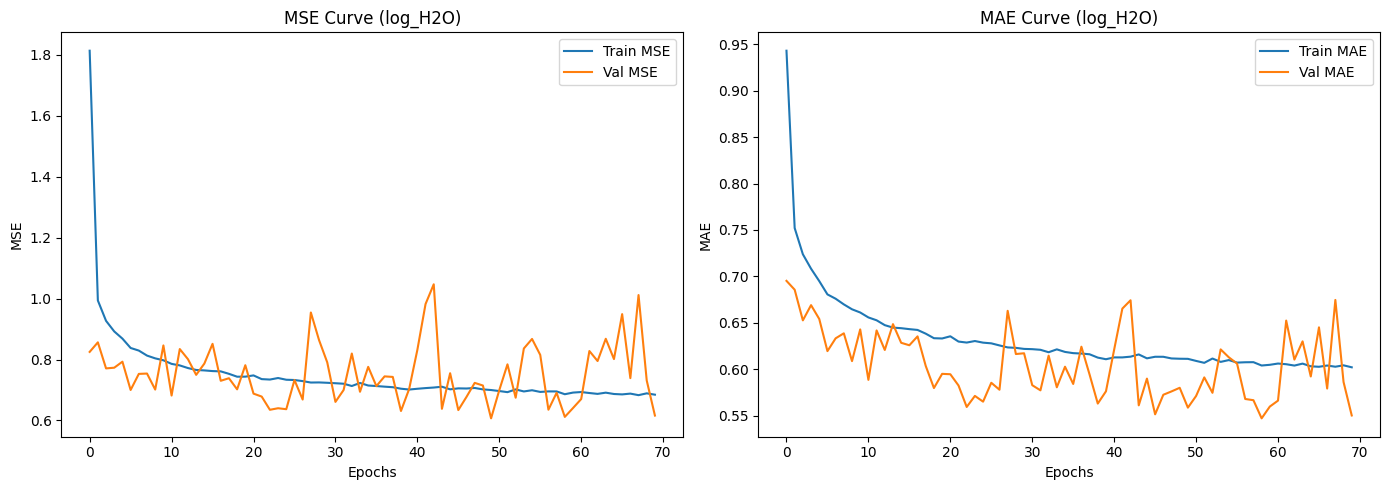

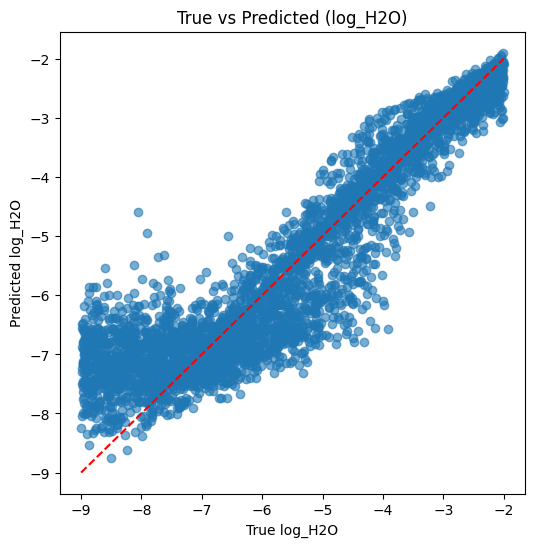

In [ ]:
#  Plot training curves and results
plot_training_and_results(history, model, X_test, y_test, target_name=target)

In [ ]:
show_random_predictions(model, X_test, y_test, n_samples=20, target_name=target)


 Predictions for 20 Random Test Samples (log_H2O):
Sample 1: True=-8.1059, Pred=-7.0247
Sample 2: True=-3.6675, Pred=-3.6463
Sample 3: True=-6.0877, Pred=-6.5945
Sample 4: True=-6.0782, Pred=-7.2681
Sample 5: True=-6.1414, Pred=-6.2997
Sample 6: True=-7.7701, Pred=-6.5485
Sample 7: True=-6.5005, Pred=-6.5621
Sample 8: True=-6.5620, Pred=-6.4432
Sample 9: True=-5.2226, Pred=-5.3270
Sample 10: True=-8.7627, Pred=-6.8573
Sample 11: True=-5.6393, Pred=-6.6580
Sample 12: True=-5.1120, Pred=-4.9563
Sample 13: True=-7.8559, Pred=-6.7250
Sample 14: True=-5.5620, Pred=-5.8934
Sample 15: True=-2.8337, Pred=-2.9091
Sample 16: True=-5.8738, Pred=-5.8050
Sample 17: True=-4.2055, Pred=-5.1508
Sample 18: True=-8.5933, Pred=-7.2106
Sample 19: True=-4.1263, Pred=-4.3907
Sample 20: True=-4.0287, Pred=-3.2971


# **log_CO2**

In [ ]:
#  target
target = "log_CO2"
X_train, X_val, X_test, y_train, y_val, y_test = prepare_data(df, target)

# Build a new model for this target
model = build_model(n_features=8, n_qubits=3, n_layers=2, n_outputs=1)


In [ ]:
# Train the model
model, history = train_model(model,
                             X_train, X_val, X_test,
                             y_train, y_val, y_test,
                             target_name=target,
                             epochs=100, batch_size=32, lr=0.001, patience=20,
                             save_dir="/content/drive/MyDrive/")

Epoch 1/100, Train MSE: 1.1381, Val MSE: 0.3243, Train MAE: 0.6756, Val MAE: 0.4336
Epoch 2/100, Train MSE: 0.3903, Val MSE: 0.2793, Train MAE: 0.4753, Val MAE: 0.3958
Epoch 3/100, Train MSE: 0.3551, Val MSE: 0.2669, Train MAE: 0.4503, Val MAE: 0.3845
Epoch 4/100, Train MSE: 0.3304, Val MSE: 0.2752, Train MAE: 0.4331, Val MAE: 0.3897
Epoch 5/100, Train MSE: 0.3115, Val MSE: 0.2573, Train MAE: 0.4190, Val MAE: 0.3793
Epoch 6/100, Train MSE: 0.3053, Val MSE: 0.2395, Train MAE: 0.4136, Val MAE: 0.3569
Epoch 7/100, Train MSE: 0.2989, Val MSE: 0.2418, Train MAE: 0.4081, Val MAE: 0.3549
Epoch 8/100, Train MSE: 0.2889, Val MSE: 0.3697, Train MAE: 0.4000, Val MAE: 0.4379
Epoch 9/100, Train MSE: 0.2839, Val MSE: 0.2206, Train MAE: 0.3971, Val MAE: 0.3418
Epoch 10/100, Train MSE: 0.2782, Val MSE: 0.2545, Train MAE: 0.3926, Val MAE: 0.3576
Epoch 11/100, Train MSE: 0.2752, Val MSE: 0.2863, Train MAE: 0.3893, Val MAE: 0.3848
Epoch 12/100, Train MSE: 0.2712, Val MSE: 0.2815, Train MAE: 0.3867, Val M

In [ ]:
# Compute test metrics
metrics, y_pred = compute_metrics(model, X_test, y_test)



Test Metrics:
RMSE=0.461, MAE=0.334, R²=0.949


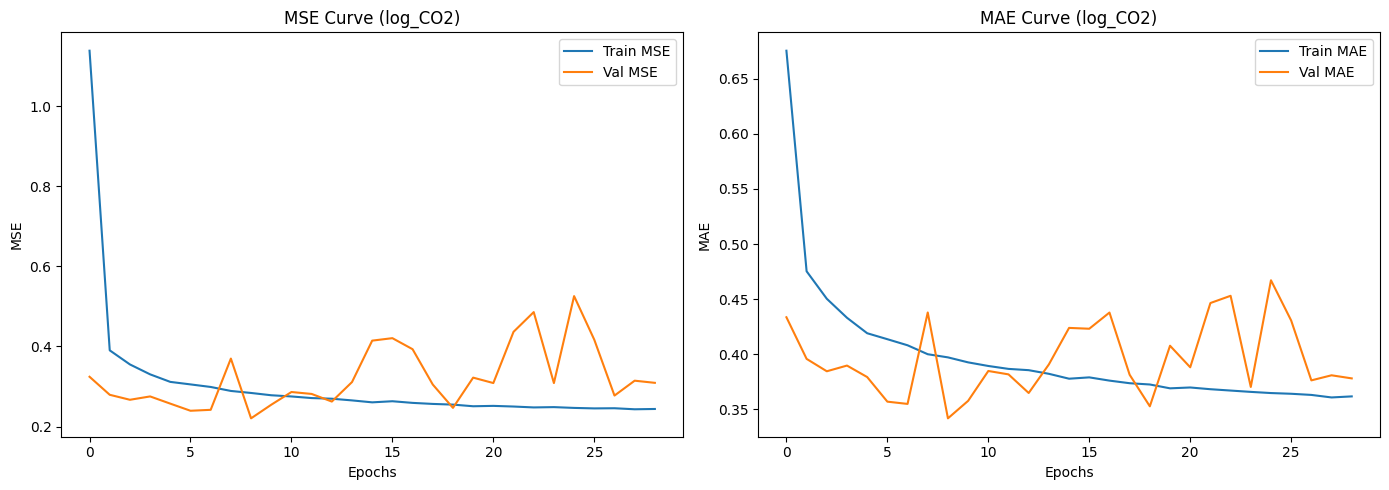

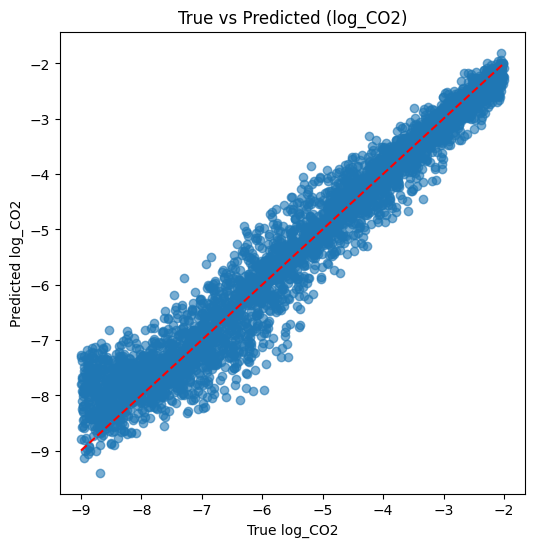

In [ ]:
# Plot training curves and results
plot_training_and_results(history, model, X_test, y_test, target_name=target)



In [ ]:
# Show random test predictions
show_random_predictions(model, X_test, y_test, n_samples=20, target_name=target)


 Predictions for 20 Random Test Samples (log_CO2):
Sample 1: True=-6.1076, Pred=-5.6601
Sample 2: True=-2.9924, Pred=-2.9702
Sample 3: True=-3.3271, Pred=-3.4514
Sample 4: True=-4.2980, Pred=-4.0721
Sample 5: True=-4.7860, Pred=-4.3889
Sample 6: True=-4.3841, Pred=-4.1124
Sample 7: True=-3.4748, Pred=-3.6681
Sample 8: True=-3.1447, Pred=-3.9092
Sample 9: True=-4.5172, Pred=-3.7370
Sample 10: True=-8.8387, Pred=-7.4882
Sample 11: True=-5.2532, Pred=-5.1314
Sample 12: True=-6.3337, Pred=-6.3249
Sample 13: True=-2.7020, Pred=-2.5836
Sample 14: True=-6.2224, Pred=-5.5028
Sample 15: True=-2.2496, Pred=-2.2702
Sample 16: True=-5.0872, Pred=-4.9120
Sample 17: True=-3.2671, Pred=-3.1197
Sample 18: True=-8.4332, Pred=-7.3930
Sample 19: True=-6.8076, Pred=-6.5114
Sample 20: True=-2.1792, Pred=-2.3001


# **log_CO**

In [ ]:
target = "log_CO"
X_train, X_val, X_test, y_train, y_val, y_test = prepare_data(df, target)

# Build a new model for this target
model = build_model(n_features=8, n_qubits=3, n_layers=2, n_outputs=1)

In [ ]:
# Train the model
model, history = train_model(model,
                             X_train, X_val, X_test,
                             y_train, y_val, y_test,
                             target_name=target,
                             epochs=200, batch_size=32, lr=0.001, patience=20,
                             save_dir="/content/drive/MyDrive/")

Epoch 1/200, Train MSE: 3.4173, Val MSE: 2.4687, Train MAE: 1.4623, Val MAE: 1.2547
Epoch 2/200, Train MSE: 2.5920, Val MSE: 2.3839, Train MAE: 1.3003, Val MAE: 1.2254
Epoch 3/200, Train MSE: 2.4989, Val MSE: 2.2705, Train MAE: 1.2681, Val MAE: 1.1971
Epoch 4/200, Train MSE: 2.4400, Val MSE: 2.2042, Train MAE: 1.2493, Val MAE: 1.1658
Epoch 5/200, Train MSE: 2.3943, Val MSE: 2.1939, Train MAE: 1.2336, Val MAE: 1.1727
Epoch 6/200, Train MSE: 2.3513, Val MSE: 2.0729, Train MAE: 1.2205, Val MAE: 1.1430
Epoch 7/200, Train MSE: 2.3345, Val MSE: 2.0520, Train MAE: 1.2156, Val MAE: 1.1148
Epoch 8/200, Train MSE: 2.3073, Val MSE: 2.0062, Train MAE: 1.2050, Val MAE: 1.1152
Epoch 9/200, Train MSE: 2.2836, Val MSE: 2.0055, Train MAE: 1.1987, Val MAE: 1.1081
Epoch 10/200, Train MSE: 2.2699, Val MSE: 2.0964, Train MAE: 1.1927, Val MAE: 1.1311
Epoch 11/200, Train MSE: 2.2702, Val MSE: 2.0686, Train MAE: 1.1932, Val MAE: 1.1014
Epoch 12/200, Train MSE: 2.2484, Val MSE: 2.0360, Train MAE: 1.1867, Val M

In [ ]:
# Compute test metrics
metrics, y_pred = compute_metrics(model, X_test, y_test)


Test Metrics:
RMSE=1.328, MAE=1.033, R²=0.564


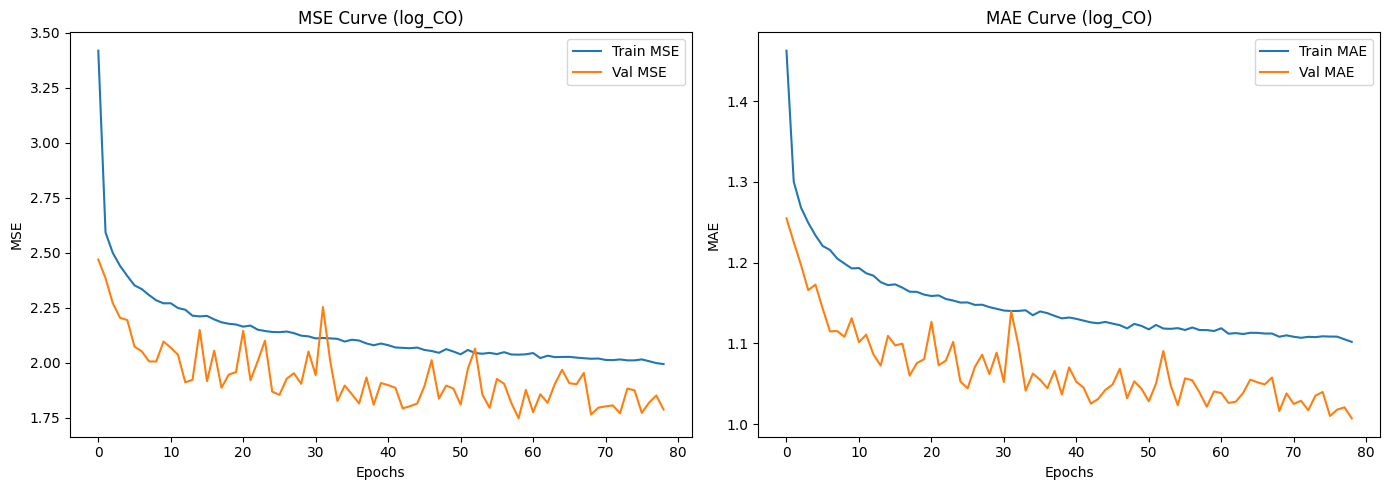

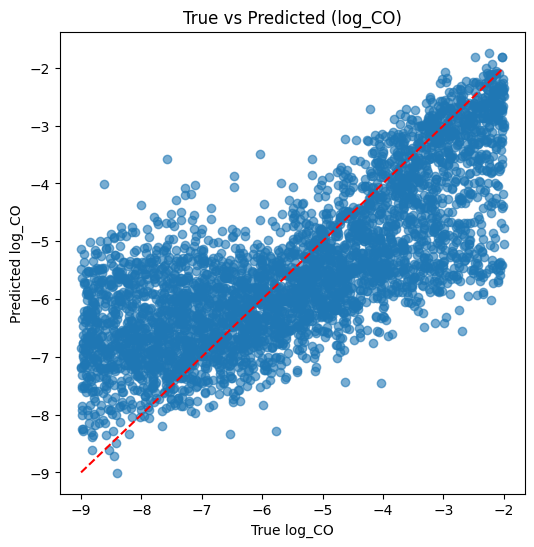

In [ ]:
# Plot training curves and results
plot_training_and_results(history, model, X_test, y_test, target_name=target)

In [ ]:
# Show random test predictions
show_random_predictions(model, X_test, y_test, n_samples=20, target_name=target)


 Predictions for 20 Random Test Samples (log_CO):
Sample 1: True=-2.3566, Pred=-2.6266
Sample 2: True=-6.3644, Pred=-6.8110
Sample 3: True=-6.9810, Pred=-6.0182
Sample 4: True=-8.4466, Pred=-4.9201
Sample 5: True=-5.4700, Pred=-5.6866
Sample 6: True=-3.4891, Pred=-6.1136
Sample 7: True=-3.6374, Pred=-5.5656
Sample 8: True=-8.1917, Pred=-5.3487
Sample 9: True=-8.9314, Pred=-6.6659
Sample 10: True=-8.3925, Pred=-5.6564
Sample 11: True=-2.8934, Pred=-2.8754
Sample 12: True=-5.9981, Pred=-5.3192
Sample 13: True=-8.1801, Pred=-6.9449
Sample 14: True=-3.8350, Pred=-5.3873
Sample 15: True=-6.2077, Pred=-5.8148
Sample 16: True=-3.5821, Pred=-3.7637
Sample 17: True=-4.4967, Pred=-4.0657
Sample 18: True=-7.6782, Pred=-6.4729
Sample 19: True=-7.9277, Pred=-5.4856
Sample 20: True=-8.7270, Pred=-7.2457


# **log_CH4**

In [ ]:
target = "log_CH4"
X_train, X_val, X_test, y_train, y_val, y_test = prepare_data(df, target)

# Build a new model for this target
model = build_model(n_features=8, n_qubits=3, n_layers=2, n_outputs=1)

In [ ]:
# Train the model
model, history = train_model(model,
                             X_train, X_val, X_test,
                             y_train, y_val, y_test,
                             target_name=target,
                             epochs=200, batch_size=32, lr=0.001, patience=20,
                             save_dir="/content/drive/MyDrive/")

Epoch 1/200, Train MSE: 1.4266, Val MSE: 0.8182, Train MAE: 0.8278, Val MAE: 0.6745
Epoch 2/200, Train MSE: 0.8104, Val MSE: 0.6640, Train MAE: 0.6733, Val MAE: 0.6058
Epoch 3/200, Train MSE: 0.7622, Val MSE: 0.6699, Train MAE: 0.6504, Val MAE: 0.5958
Epoch 4/200, Train MSE: 0.7271, Val MSE: 0.6221, Train MAE: 0.6326, Val MAE: 0.5721
Epoch 5/200, Train MSE: 0.7124, Val MSE: 0.6563, Train MAE: 0.6232, Val MAE: 0.6022
Epoch 6/200, Train MSE: 0.6952, Val MSE: 0.6816, Train MAE: 0.6125, Val MAE: 0.5761
Epoch 7/200, Train MSE: 0.6892, Val MSE: 0.6122, Train MAE: 0.6085, Val MAE: 0.5540
Epoch 8/200, Train MSE: 0.6778, Val MSE: 0.6366, Train MAE: 0.6025, Val MAE: 0.6007
Epoch 9/200, Train MSE: 0.6665, Val MSE: 0.6166, Train MAE: 0.5949, Val MAE: 0.5591
Epoch 10/200, Train MSE: 0.6555, Val MSE: 0.6101, Train MAE: 0.5899, Val MAE: 0.5628
Epoch 11/200, Train MSE: 0.6561, Val MSE: 0.5786, Train MAE: 0.5885, Val MAE: 0.5392
Epoch 12/200, Train MSE: 0.6531, Val MSE: 0.6499, Train MAE: 0.5878, Val M

In [ ]:
# Compute test metrics
metrics, y_pred = compute_metrics(model, X_test, y_test)


Test Metrics:
RMSE=0.704, MAE=0.494, R²=0.879


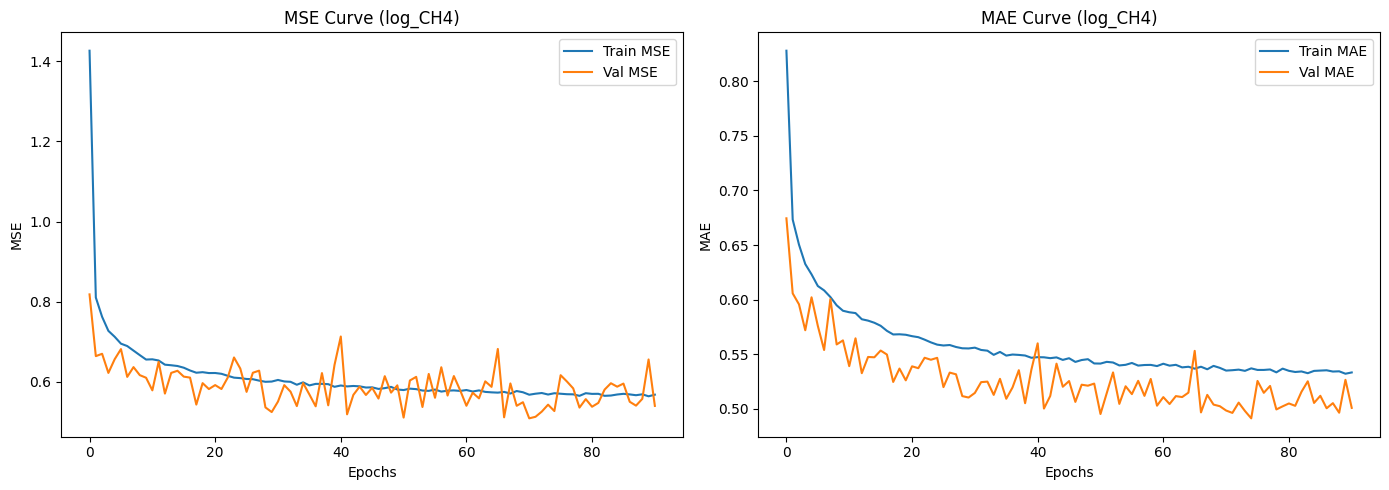

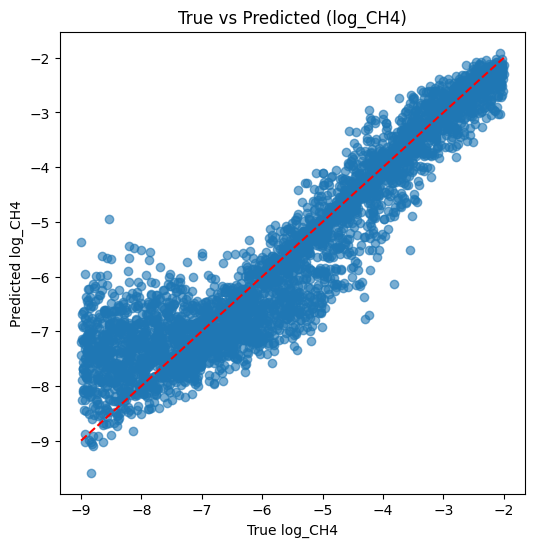

In [ ]:
# Plot training curves and results
plot_training_and_results(history, model, X_test, y_test, target_name=target)

In [ ]:
# Show random test predictions
show_random_predictions(model, X_test, y_test, n_samples=20, target_name=target)


 Predictions for 20 Random Test Samples (log_CH4):
Sample 1: True=-8.4960, Pred=-7.9266
Sample 2: True=-8.3760, Pred=-6.2372
Sample 3: True=-6.7511, Pred=-6.4252
Sample 4: True=-6.4182, Pred=-6.3302
Sample 5: True=-8.8782, Pred=-7.0541
Sample 6: True=-7.2440, Pred=-6.8497
Sample 7: True=-3.0223, Pred=-2.8060
Sample 8: True=-3.3327, Pred=-3.3929
Sample 9: True=-7.6922, Pred=-6.9171
Sample 10: True=-6.8987, Pred=-7.2972
Sample 11: True=-3.8406, Pred=-3.9035
Sample 12: True=-3.3605, Pred=-3.7009
Sample 13: True=-7.4534, Pred=-6.5022
Sample 14: True=-8.9014, Pred=-8.0235
Sample 15: True=-7.9800, Pred=-8.0506
Sample 16: True=-2.6424, Pred=-2.6750
Sample 17: True=-8.5437, Pred=-7.9329
Sample 18: True=-4.5252, Pred=-4.5646
Sample 19: True=-2.7363, Pred=-2.7487
Sample 20: True=-7.3320, Pred=-7.0203


# **log_NH3**

In [ ]:
target = "log_NH3"
X_train, X_val, X_test, y_train, y_val, y_test = prepare_data(df, target)

# Build a new model for this target
model = build_model(n_features=8, n_qubits=3, n_layers=2, n_outputs=1)

In [ ]:
# Train the model
model, history = train_model(model,
                             X_train, X_val, X_test,
                             y_train, y_val, y_test,
                             target_name=target,
                             epochs=200, batch_size=32, lr=0.001, patience=20,
                             save_dir="/content/drive/MyDrive/")

Epoch 1/200, Train MSE: 1.5903, Val MSE: 0.8444, Train MAE: 0.8819, Val MAE: 0.6809
Epoch 2/200, Train MSE: 0.9233, Val MSE: 0.7558, Train MAE: 0.7239, Val MAE: 0.6397
Epoch 3/200, Train MSE: 0.8554, Val MSE: 0.7793, Train MAE: 0.6943, Val MAE: 0.6616
Epoch 4/200, Train MSE: 0.8232, Val MSE: 0.7184, Train MAE: 0.6789, Val MAE: 0.6289
Epoch 5/200, Train MSE: 0.8041, Val MSE: 0.7200, Train MAE: 0.6702, Val MAE: 0.6250
Epoch 6/200, Train MSE: 0.7827, Val MSE: 0.7188, Train MAE: 0.6602, Val MAE: 0.6374
Epoch 7/200, Train MSE: 0.7756, Val MSE: 0.6962, Train MAE: 0.6572, Val MAE: 0.6072
Epoch 8/200, Train MSE: 0.7677, Val MSE: 0.6581, Train MAE: 0.6514, Val MAE: 0.6149
Epoch 9/200, Train MSE: 0.7588, Val MSE: 0.6635, Train MAE: 0.6474, Val MAE: 0.5946
Epoch 10/200, Train MSE: 0.7484, Val MSE: 0.6614, Train MAE: 0.6426, Val MAE: 0.6023
Epoch 11/200, Train MSE: 0.7474, Val MSE: 0.6111, Train MAE: 0.6402, Val MAE: 0.5727
Epoch 12/200, Train MSE: 0.7428, Val MSE: 0.6564, Train MAE: 0.6390, Val M

KeyboardInterrupt: 

In [ ]:
# Compute test metrics
metrics, y_pred = compute_metrics(model, X_test, y_test)


Test Metrics:
RMSE=0.754, MAE=0.539, R²=0.860


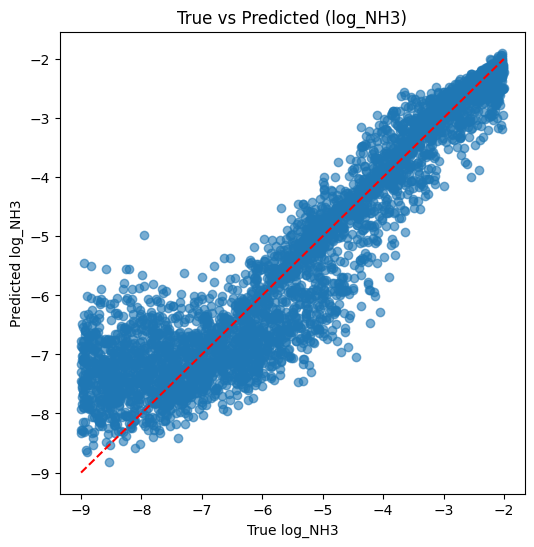

In [ ]:
model.load_state_dict(torch.load("/content/drive/MyDrive/qnn_best_log_NH3.pth"))
model.eval()

# 2. Run predictions on test set
with torch.no_grad():
    y_pred = model(X_test, X_test).numpy()

# 3. Make scatter plot
import matplotlib.pyplot as plt

plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')  # diagonal line
plt.xlabel(f"True {target}")
plt.ylabel(f"Predicted {target}")
plt.title(f"True vs Predicted ({target})")
plt.show()

In [ ]:
# Show random test predictions
show_random_predictions(model, X_test, y_test, n_samples=20, target_name=target)


 Predictions for 20 Random Test Samples (log_NH3):
Sample 1: True=-4.6516, Pred=-4.2564
Sample 2: True=-7.1152, Pred=-7.3404
Sample 3: True=-4.8625, Pred=-5.4769
Sample 4: True=-4.7038, Pred=-6.1622
Sample 5: True=-3.5515, Pred=-3.1775
Sample 6: True=-7.2662, Pred=-7.5077
Sample 7: True=-5.4560, Pred=-5.7237
Sample 8: True=-4.6934, Pred=-7.0468
Sample 9: True=-6.8002, Pred=-7.1425
Sample 10: True=-5.3799, Pred=-5.0472
Sample 11: True=-4.2053, Pred=-4.4834
Sample 12: True=-2.9977, Pred=-3.0185
Sample 13: True=-6.9878, Pred=-7.4347
Sample 14: True=-8.8619, Pred=-7.2789
Sample 15: True=-8.1986, Pred=-7.5145
Sample 16: True=-6.4798, Pred=-5.9941
Sample 17: True=-5.3733, Pred=-6.4201
Sample 18: True=-5.2466, Pred=-5.3762
Sample 19: True=-7.6029, Pred=-7.9876
Sample 20: True=-4.4942, Pred=-5.9391


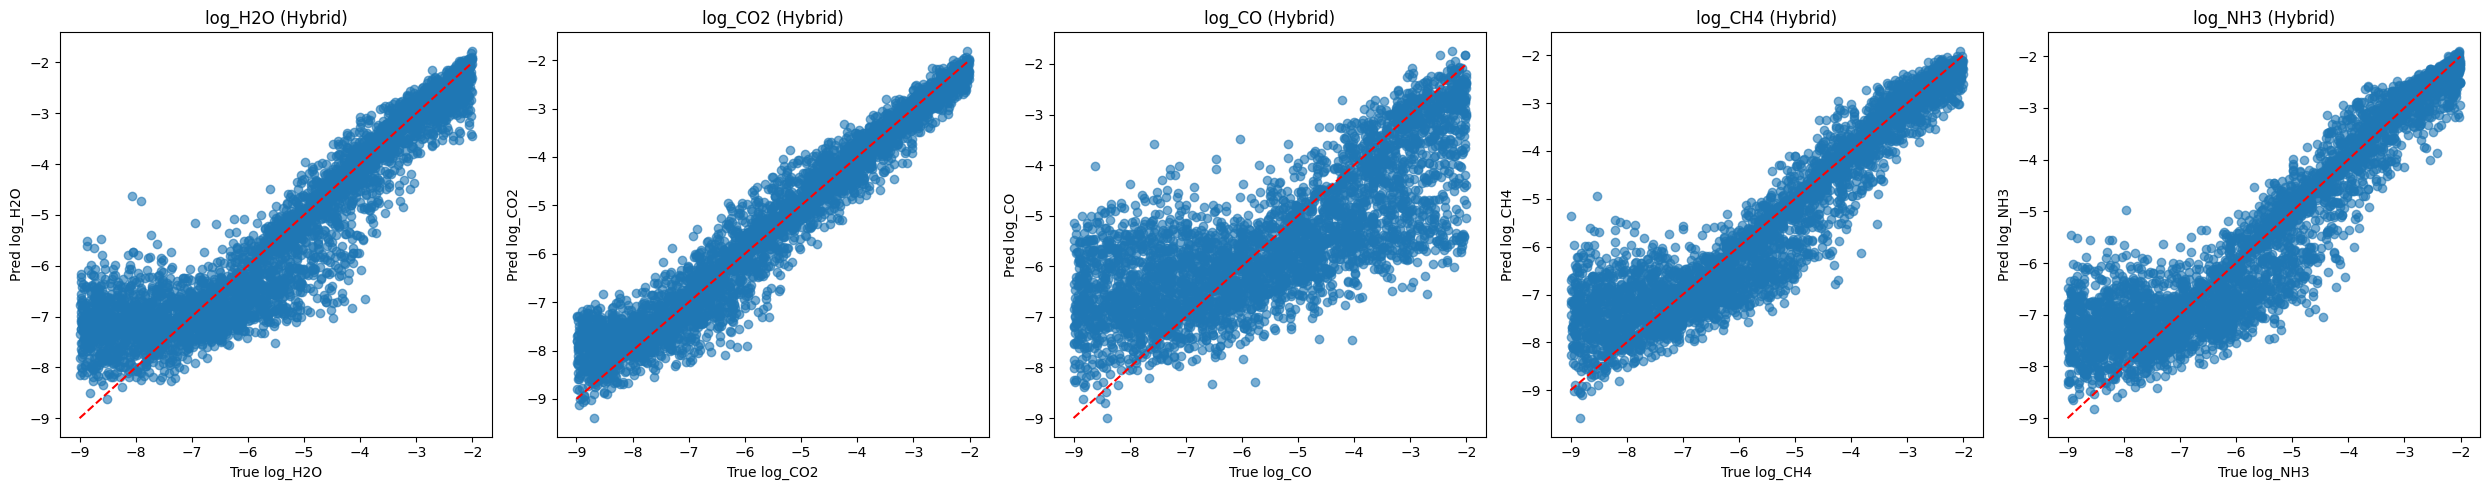

In [ ]:
targets = ["log_H2O", "log_CO2", "log_CO", "log_CH4", "log_NH3"]

histories = {}
predictions = {}
true_values = {}

for target in targets:

    model = build_model(n_features=8, n_qubits=3, n_layers=2, n_outputs=1)
    model.load_state_dict(torch.load(f"/content/drive/MyDrive/qnn_best_{target}.pth"))
    model.eval()

    X_train, X_val, X_test, y_train, y_val, y_test = prepare_data(df, target)

    with torch.no_grad():
        y_pred = model(X_test, X_test).cpu().numpy()

    predictions[target] = y_pred
    true_values[target] = y_test.cpu().numpy()


fig, axes = plt.subplots(1, len(targets), figsize=(5 * len(targets), 5))

if len(targets) == 1:
    axes = [axes]

for ax, target in zip(axes, targets):
    y_true = true_values[target]
    y_pred = predictions[target]

    ax.scatter(y_true, y_pred, alpha=0.6)
    ax.plot([y_true.min(), y_true.max()],
            [y_true.min(), y_true.max()], 'r--')
    ax.set_xlabel(f"True {target}")
    ax.set_ylabel(f"Pred {target}")
    ax.set_title(f"{target} (Hybrid)")

plt.tight_layout()
plt.show()


In [ ]:
target_cols = ["log_H2O", "log_CO2", "log_CO", "log_CH4", "log_NH3"]

batch_size = 32
qnn_contributions = {}

for target in target_cols:
    # Build model and load saved weights
    model = build_model(n_features=8, n_qubits=3, n_layers=2, n_outputs=1)
    model.load_state_dict(torch.load(f"/content/drive/MyDrive/qnn_best_{target}.pth"))
    model.eval()

    # Get training data for this target
    X_train, X_val, X_test, y_train, y_val, y_test = prepare_data(df, target)

    # Collect QNN-only outputs for the training set
    with torch.no_grad():
        q_out = []
        for i in range(0, len(X_train), batch_size):
            q_out.append(model.qnn(X_train[i:i+batch_size]).cpu().numpy())
        q_out = np.vstack(q_out)

    # Compute per-qubit standard deviation
    qnn_std = np.std(q_out, axis=0)
    qnn_contributions[target] = qnn_std

    print(f"{target} -> QNN output std per qubit: {qnn_std}")


log_H2O -> QNN output std per qubit: [0.22423516 0.23262425 0.22671002]
log_CO2 -> QNN output std per qubit: [0.15585124 0.28362536 0.38459143]
log_CO -> QNN output std per qubit: [0.27636695 0.22204888 0.18495262]
log_CH4 -> QNN output std per qubit: [0.28016508 0.30455717 0.25014845]
log_NH3 -> QNN output std per qubit: [0.20786346 0.21391967 0.22545998]
